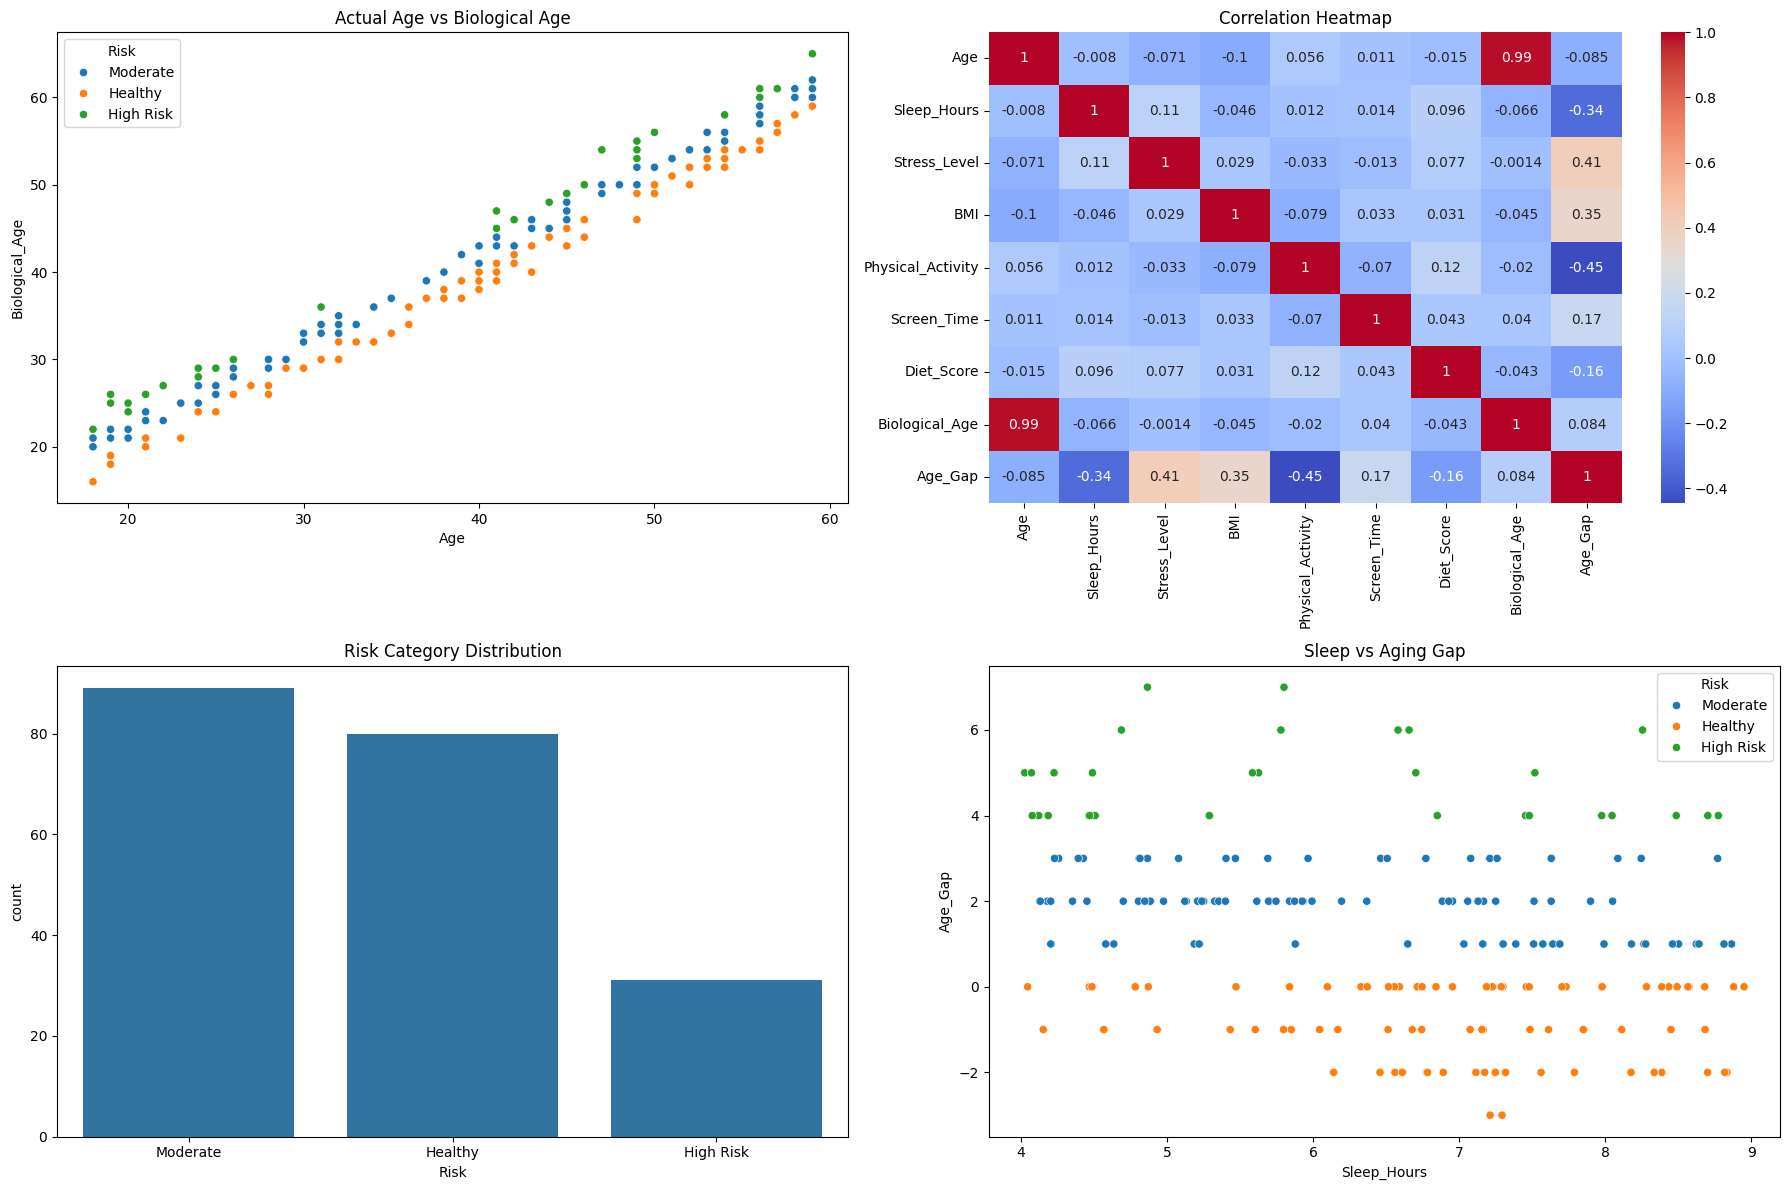


===== KEY INSIGHTS =====

Average Biological Age: 39.96
Average Actual Age: 38.66

High Risk Percentage: 15.5 %

Avg Age Gap for Low Sleep (<6 hrs): 2.3
Avg Age Gap for High Stress (>7): 3.54


In [1]:
# ================================
# Biological Age vs Lifestyle Age Analyzer
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -------------------------------
# 1. Create Synthetic Dataset
# -------------------------------
n = 200

data = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Sleep_Hours": np.random.uniform(4, 9, n),
    "Stress_Level": np.random.randint(1, 10, n),
    "BMI": np.random.uniform(18, 35, n),
    "Physical_Activity": np.random.randint(0, 7, n),
    "Screen_Time": np.random.uniform(2, 10, n),
    "Diet_Score": np.random.randint(1, 10, n)
})

# -------------------------------
# 2. Calculate Biological Age
# -------------------------------
def calculate_bio_age(row):
    bio_age = row["Age"]

    # Add risk factors
    if row["Sleep_Hours"] < 6:
        bio_age += 2
    if row["Stress_Level"] > 7:
        bio_age += 3
    if row["BMI"] > 30:
        bio_age += 2
    if row["Screen_Time"] > 7:
        bio_age += 1

    # Reduce age for good habits
    if row["Physical_Activity"] > 4:
        bio_age -= 2
    if row["Diet_Score"] > 7:
        bio_age -= 1

    return bio_age

data["Biological_Age"] = data.apply(calculate_bio_age, axis=1)

# Age Gap
data["Age_Gap"] = data["Biological_Age"] - data["Age"]

# Risk Category
def risk_category(gap):
    if gap <= 0:
        return "Healthy"
    elif gap <= 3:
        return "Moderate"
    else:
        return "High Risk"

data["Risk"] = data["Age_Gap"].apply(risk_category)

# -------------------------------
# 3. Visualization
# -------------------------------
plt.figure(figsize=(18, 12))

# Scatter Plot
plt.subplot(2, 2, 1)
sns.scatterplot(x="Age", y="Biological_Age", hue="Risk", data=data)
plt.title("Actual Age vs Biological Age")

# Heatmap
plt.subplot(2, 2, 2)
corr = data.drop(columns=["Risk"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

# Risk Count
plt.subplot(2, 2, 3)
sns.countplot(x="Risk", data=data)
plt.title("Risk Category Distribution")

# Sleep vs Age Gap
plt.subplot(2, 2, 4)
sns.scatterplot(x="Sleep_Hours", y="Age_Gap", hue="Risk", data=data)
plt.title("Sleep vs Aging Gap")

plt.tight_layout()
plt.show()

# -------------------------------
# 4. Key Insights
# -------------------------------
print("\n===== KEY INSIGHTS =====\n")

print("Average Biological Age:", round(data["Biological_Age"].mean(), 2))
print("Average Actual Age:", round(data["Age"].mean(), 2))

high_risk = data[data["Risk"] == "High Risk"]

print("\nHigh Risk Percentage:", round(len(high_risk)/len(data)*100, 2), "%")

low_sleep = data[data["Sleep_Hours"] < 6]["Age_Gap"].mean()
print("\nAvg Age Gap for Low Sleep (<6 hrs):", round(low_sleep, 2))

high_stress = data[data["Stress_Level"] > 7]["Age_Gap"].mean()
print("Avg Age Gap for High Stress (>7):", round(high_stress, 2))